# The AI Power Map
## Entrega 6: PCA, t-SNE y Componente Avanzado
### Equipo: DataChasquiAILab | Semana 15


### Introducción

Esta entrega aplica reducción de dimensionalidad sobre el dataset Gold para identificar
patrones ocultos en el ecosistema global de IA que no son visibles en gráficos simples.

### ¿Qué es PCA?
PCA (Principal Component Analysis) reduce muchas variables a pocas dimensiones
preservando la mayor cantidad de varianza posible. Revela **estructura global**:
cómo se distribuyen los modelos en el espacio de características técnicas.

### ¿Qué es t-SNE?
t-SNE (t-Distributed Stochastic Neighbor Embedding) revela **estructura local**:
agrupa modelos similares entre sí. No preserva distancias globales, solo vecindarios.

### ¿Por qué ambos?
| Técnica | Preserva | No preserva | Uso |
|---|---|---|---|
| PCA | Estructura global, varianza | Vecindarios locales | Entender qué variables importan |
| t-SNE | Vecindarios locales | Distancias globales | Visualizar clusters |

### Variables seleccionadas para el modelo
Usamos las variables dummy (0/1) y logarítmicas que tienen cobertura completa,
ya que PCA y t-SNE no toleran nulos.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from src.io_utils import save_csv
from src.config import OUTPUTS_TABLEAU

sns.set_theme(style='whitegrid', context='talk')
RANDOM_STATE = 42

df = pd.read_csv(PROJECT_ROOT / 'outputs/tableau/fact_models_gold.csv')
print(f'Dataset Gold cargado: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset Gold cargado: 3405 filas x 45 columnas


---
## 1. Selección y preparación de variables

Seleccionamos variables con cobertura completa (0 nulos).
Las variables logarítmicas reemplazan a las originales porque tienen
distribución menos sesgada: mejor para PCA.
Las variables dummy aportan contexto categórico sin introducir escala artificial.

In [2]:
FEATURES = [
    # Variables logarítmicas: cobertura parcial pero las más importantes
    'log_parameters',
    'log_training_compute_flop',
    'log_citations',
    # Temporales
    'Year',
    'es_post_2020',
    'es_post_2017',
    # Dominio
    'es_language',
    'es_vision',
    'es_biology',
    'es_multimodal',
    'es_image_generation',
    'es_speech',
    # Organización
    'es_industry',
    'es_academia',
    # Acceso
    'es_abierto',
]

df_model = df[['Model', 'Organization', 'Country (of organization)',
               'bloque_geopolitico', 'era_tecnologica', 'Domain'] + FEATURES].copy()

# Eliminamos filas con nulos en las features
antes = len(df_model)
df_model = df_model.dropna(subset=FEATURES)
print(f'Filas antes: {antes} | Después de eliminar nulos: {len(df_model)}')
print(f'Features seleccionadas: {len(FEATURES)}')

X = df_model[FEATURES].values
print(f'Matrix X: {X.shape}')

Filas antes: 3405 | Después de eliminar nulos: 632
Features seleccionadas: 15
Matrix X: (632, 15)


---
## 2. Escalado con StandardScaler

PCA es sensible a la escala: una variable con valores grandes dominaría
los componentes. StandardScaler centra cada variable en media 0 y desviación 1.

**¿Por qué StandardScaler y no MinMaxScaler?**
MinMaxScaler es sensible a outliers extremos. Nuestras variables tienen
outliers incluso después del logaritmo. StandardScaler es más robusto.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Media ~0: {X_scaled.mean():.4f}')
print(f'Desv ~1:  {X_scaled.std():.4f}')

Media ~0: -0.0000
Desv ~1:  1.0000


---
## 3. PCA: Varianza explicada

Primero corremos PCA completo para ver cuántos componentes necesitamos
para retener el 90% de la varianza del dataset.

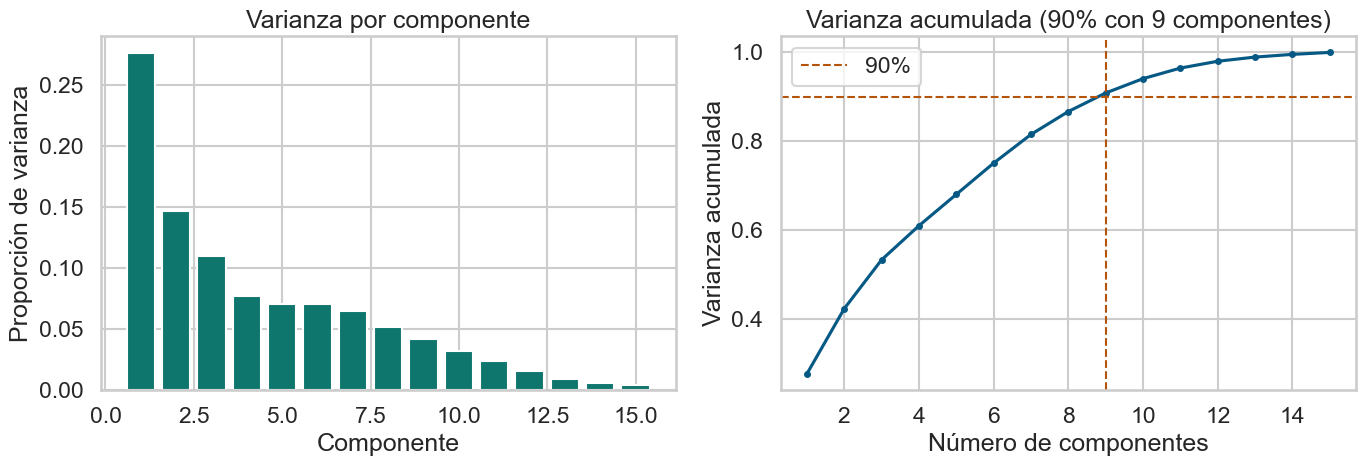

PC1 explica 27.6% | PC2 explica 14.7%
Se necesitan 9 de 15 componentes para retener el 90% de varianza


In [4]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(var_ratio)+1), var_ratio, color='#0f766e')
axes[0].set_title('Varianza por componente')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, len(cum_var)+1), cum_var, color='#075985', marker='o', ms=4)
axes[1].axhline(0.90, color='#b45309', ls='--', lw=1.5, label='90%')
axes[1].axvline(n_90, color='#b45309', ls='--', lw=1.5)
axes[1].set_title(f'Varianza acumulada (90% con {n_90} componentes)')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs/reports/pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 explica {var_ratio[0]:.1%} | PC2 explica {var_ratio[1]:.1%}')
print(f'Se necesitan {n_90} de {len(var_ratio)} componentes para retener el 90% de varianza')

---
## 4. PCA 2D: Proyección y visualización

Reducimos a 2 dimensiones para visualizar la estructura global.
Coloreamos por bloque geopolítico para responder la pregunta del proyecto:
¿se agrupan los modelos por país de origen?

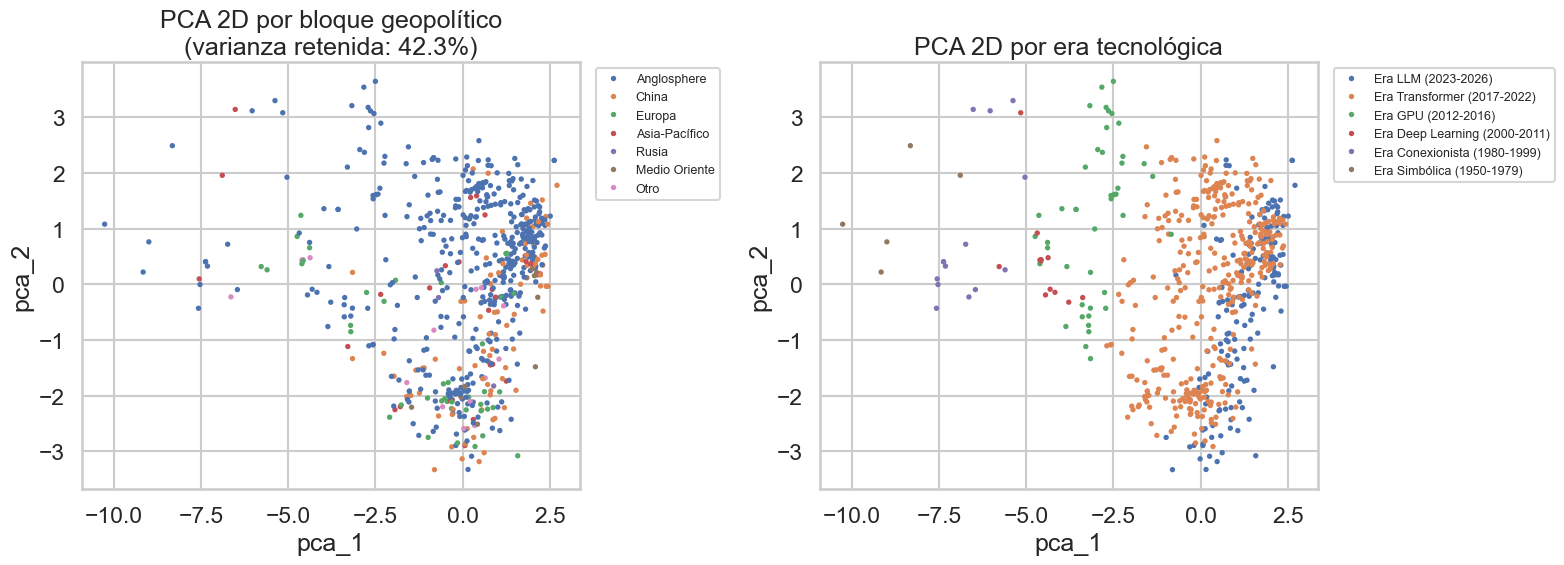

PC1: 27.6% | PC2: 14.7%


In [5]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pca = pca2.fit_transform(X_scaled)
df_model['pca_1'] = coords_pca[:, 0]
df_model['pca_2'] = coords_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por bloque geopolítico
sns.scatterplot(data=df_model, x='pca_1', y='pca_2',
                hue='bloque_geopolitico', s=15, linewidth=0,
                legend='full', ax=axes[0])
axes[0].set_title(f'PCA 2D por bloque geopolítico\n(varianza retenida: {pca2.explained_variance_ratio_.sum():.1%})')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

# Por era tecnológica
sns.scatterplot(data=df_model, x='pca_1', y='pca_2',
                hue='era_tecnologica', s=15, linewidth=0,
                legend='full', ax=axes[1])
axes[1].set_title('PCA 2D por era tecnológica')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs/reports/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1: {pca2.explained_variance_ratio_[0]:.1%} | PC2: {pca2.explained_variance_ratio_[1]:.1%}')

---
## 5. Loadings: ¿Qué variables forman cada componente?

Los loadings indican qué variables contribuyen más a cada componente principal.
Esto nos permite interpretar qué significa PC1 y PC2 en términos del negocio.

In [6]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
).round(3)

print('Loadings PC1 y PC2 (variables que más contribuyen):')
print(loadings.sort_values('PC1', ascending=False).to_string())

Loadings PC1 y PC2 (variables que más contribuyen):
                             PC1    PC2
log_training_compute_flop  0.441  0.074
log_parameters             0.412  0.074
Year                       0.408 -0.131
es_post_2017               0.383 -0.175
es_post_2020               0.360 -0.139
es_abierto                 0.191  0.057
es_industry                0.190  0.523
es_language                0.103 -0.131
es_multimodal              0.099  0.112
es_biology                 0.059 -0.257
es_image_generation        0.040  0.089
log_citations             -0.101  0.455
es_speech                 -0.124  0.071
es_vision                 -0.161  0.258
es_academia               -0.209 -0.512


---
## 6. t-SNE: Estructura local

Aplicamos PCA a 10 componentes primero (recomendación estándar) para
reducir ruido antes de t-SNE. Luego t-SNE con perplexity=30.

**Límites de t-SNE:**
- No leer distancia entre clusters como significado real
- No comparar tamaño de clusters entre corridas
- Correr con distintas semillas para confirmar patrones

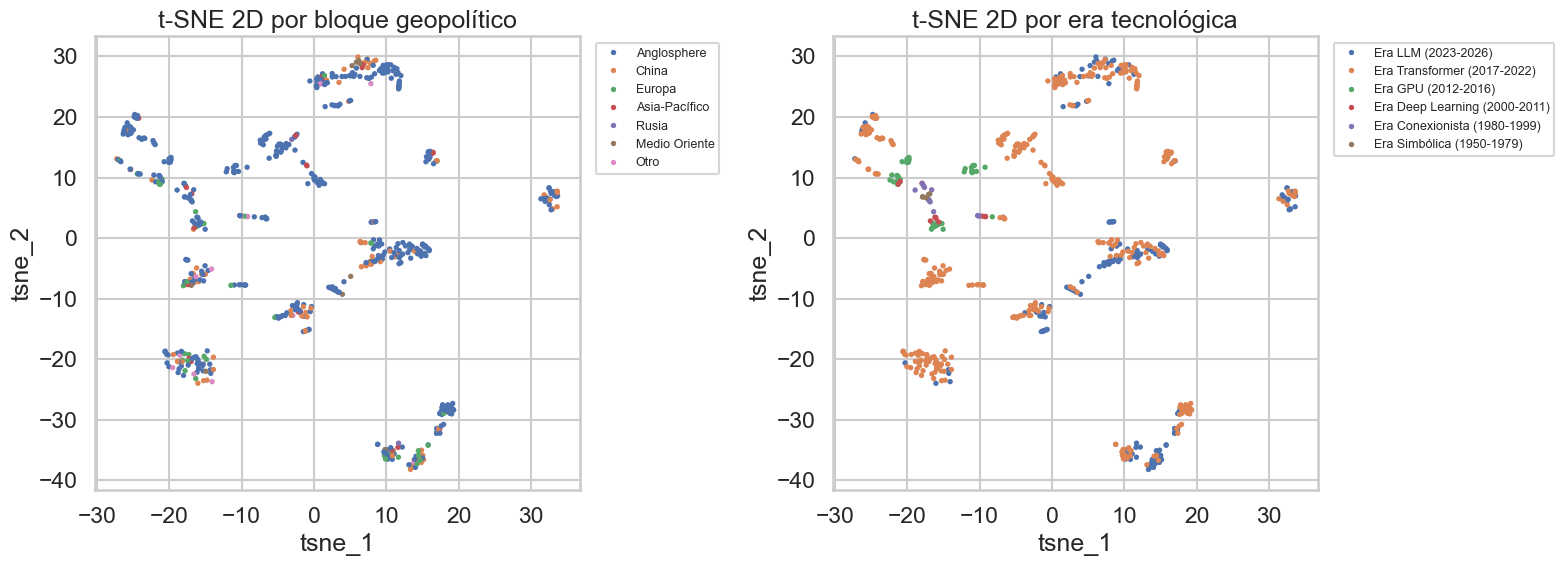

In [7]:
# PCA a 10 componentes como preprocesamiento para t-SNE
n_components_pre = min(10, len(FEATURES))
X_pca_pre = PCA(n_components=n_components_pre,
                random_state=RANDOM_STATE).fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, init='pca',
            learning_rate='auto', random_state=RANDOM_STATE)
coords_tsne = tsne.fit_transform(X_pca_pre)
df_model['tsne_1'] = coords_tsne[:, 0]
df_model['tsne_2'] = coords_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_model, x='tsne_1', y='tsne_2',
                hue='bloque_geopolitico', s=15, linewidth=0,
                legend='full', ax=axes[0])
axes[0].set_title('t-SNE 2D por bloque geopolítico')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

sns.scatterplot(data=df_model, x='tsne_1', y='tsne_2',
                hue='era_tecnologica', s=15, linewidth=0,
                legend='full', ax=axes[1])
axes[1].set_title('t-SNE 2D por era tecnológica')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs/reports/tsne_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Comparación PCA vs t-SNE

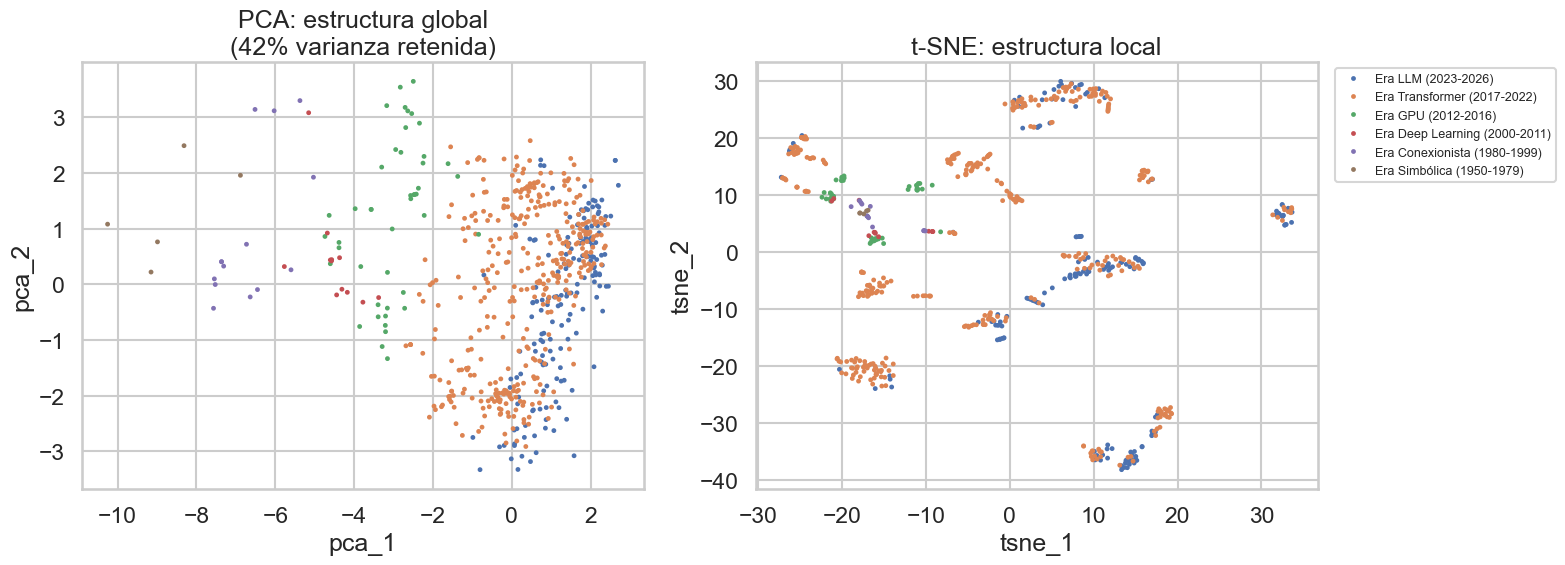

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_model, x='pca_1', y='pca_2',
                hue='era_tecnologica', s=12, linewidth=0,
                legend=False, ax=axes[0])
axes[0].set_title(f'PCA: estructura global\n({pca2.explained_variance_ratio_.sum():.0%} varianza retenida)')

sns.scatterplot(data=df_model, x='tsne_1', y='tsne_2',
                hue='era_tecnologica', s=12, linewidth=0,
                legend='full', ax=axes[1])
axes[1].set_title('t-SNE: estructura local')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs/reports/pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Exportación para Tableau

Exportamos las coordenadas PCA y t-SNE junto con los metadatos
para construir el scatter plot avanzado en Tableau.

In [9]:
# Dataset de coordenadas para Tableau
embedding = df_model[[
    'Model', 'Organization', 'Country (of organization)',
    'bloque_geopolitico', 'era_tecnologica', 'Domain',
    'pca_1', 'pca_2', 'tsne_1', 'tsne_2'
]].copy()

save_csv(embedding, OUTPUTS_TABLEAU / 'pca_tsne_embedding.csv')
print(f'✅ pca_tsne_embedding.csv exportado: {embedding.shape[0]} filas')

# Notas metodológicas
methodology = pd.DataFrame([
    {'item': 'dataset', 'value': 'Epoch AI: All AI Models (Gold)'},
    {'item': 'n_samples', 'value': len(df_model)},
    {'item': 'n_features', 'value': len(FEATURES)},
    {'item': 'scaling', 'value': 'StandardScaler'},
    {'item': 'pca_var_2d', 'value': round(float(pca2.explained_variance_ratio_.sum()), 4)},
    {'item': 'pca_components_90pct', 'value': n_90},
    {'item': 'tsne_perplexity', 'value': 30},
    {'item': 'tsne_input', 'value': f'PCA a {n_components_pre} componentes antes de t-SNE'},
    {'item': 'warning', 'value': 't-SNE preserva vecindarios locales, no distancias globales'},
])

save_csv(methodology, OUTPUTS_TABLEAU / 'pca_tsne_methodology.csv')
print(f'✅ pca_tsne_methodology.csv exportado')
print(methodology.to_string(index=False))

✅ pca_tsne_embedding.csv exportado: 632 filas
✅ pca_tsne_methodology.csv exportado
                item                                                      value
             dataset                             Epoch AI: All AI Models (Gold)
           n_samples                                                        632
          n_features                                                         15
             scaling                                             StandardScaler
          pca_var_2d                                                     0.4227
pca_components_90pct                                                          9
     tsne_perplexity                                                         30
          tsne_input                        PCA a 10 componentes antes de t-SNE
             warning t-SNE preserva vecindarios locales, no distancias globales


---
## 9. Límites interpretativos y cierre

- **PCA**: los ejes son combinaciones lineales de variables. El signo es arbitrario.
  La interpretación real viene de los loadings.
- **t-SNE**: no leer distancia entre clusters como significado real.
  Correr con otra semilla para confirmar patrones.
- **Cobertura**: el modelo usa solo los registros con las 3 variables logarítmicas
  completas: subset más rico técnicamente pero no representativo de todos los modelos.
- **Uso en dashboard**: el scatter PCA/t-SNE en Tableau es el componente avanzado
  que complementa el análisis base, no lo reemplaza.